In [1]:
!pip install scikit-learn
!pip install datasets evaluate transformers
!pip install -U datasets huggingface_hub fsspec
!pip install peft
!pip install bitsandbytes
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 16.2 MB/s eta 0:00:00


In [2]:
import re
import pandas as pd
import numpy as np
import sys
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForTokenClassification, DataCollatorForTokenClassification, TrainingArguments, Trainer
from datasets import Dataset
from peft import LoraConfig, get_peft_model
from datasets import Dataset
import evaluate
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load and analyze the processed dataset
df_filtered = pd.read_csv("processed_mobidb_data.csv")
df_filtered["length"] = df_filtered["sequences"].apply(len)
print(f"DataFrame lengths: min={df_filtered['length'].min() }, max={df_filtered['length'].max()}, mean={df_filtered['length'].mean()}")
print(df_filtered["length"].describe())
df_filtered

DataFrame lengths: min=19, max=998, mean=385.3790713790714
count    2886.000000
mean      385.379071
std       237.444943
min        19.000000
25%       192.000000
50%       334.000000
75%       542.000000
max       998.000000
Name: length, dtype: float64


,sequences,Id,transition_scores,length
0,MFSFIDDIPSFEQIKARVRDDLRKHGWEKRWNDSRLVQKSRELLND...,P16536,1111111111111111111111111111111111111111111111...,124
1,MPYKLKKEKEPPKVAKCTAKPSSSGKDGGGENTEEAQPQPQPQPQP...,Q14738,1111111111111111111111111111111111111111111111...,602
2,CLGVGSCNDFAGCGYAIVCFW,P85078,111111111112222222222,21
3,MVTPALQMKKPKQFCRRMGQKKQRPARAGQPHSSSDAAQAPAEQPH...,P29372,1111111111111111111111111111111111111111111111...,298
4,MSGGSSCSQTPSRAIPATRRVVLGDGVQLPPGDYSTTPGGTLFSTT...,Q13541,1111111111111111111111111111111111111111111111...,118
...,...,...,...,...
2881,MIITSPTEARKDFYQLLKNVNNNHEPIYISGNNAENNAVIIGLEDW...,Q2FVF7,2222222222222222222222222222222222222222222222...,85
2882,MKISENWLRTWVNPAIDSDTLSDQLTMLGLEVDELASVAKPFTGVV...,D0CA71,2222222222222222222222222222222222222222200000...,793
2883,MKIAIAGAGAMGSRFGLMLHQSGNEVLLIDGWAEHVQQIKEHGLQA...,Q3Y316,0000000000000000000000000000000000000000000000...,312
2884,MASQSQGIQQLLQAEKRAAEKVSEARKRKNRRLKQAKEEAQAEIEQ...,B2GUV5,2200000000000000000000000000000000000000000000...,118


In [4]:
# Extracting sequences and labels for training and testing
sequences = df_filtered["sequences"].tolist()
labels = []
for scores in df_filtered["transition_scores"].tolist():
    label = np.zeros(len(scores), dtype=int)
    for idx, score in enumerate(scores):
        label[idx] = int(score)
    labels.append(label)

sequences[0:3], labels[0:3]


(['MFSFIDDIPSFEQIKARVRDDLRKHGWEKRWNDSRLVQKSRELLNDEELKIDPATWIWKRMPSREEVAARRQRDFETVWKYRYRLGGFASGALLALALAGIFSTGNFGGSSDAGNRPSVVYPIE',
  'MPYKLKKEKEPPKVAKCTAKPSSSGKDGGGENTEEAQPQPQPQPQPQAQSQPPSSNKRPSNSTPPPTQLSKIKYSGGPQIVKKERRQSSSRFNLSKNRELQKLPALKDSPTQEREELFIQKLRQCCVLFDFVSDPLSDLKFKEVKRAGLNEMVEYITHSRDVVTEAIYPEAVTMFSVNLFRTLPPSSNPTGAEFDPEEDEPTLEAAWPHLQLVYEFFLRFLESPDFQPNIAKKYIDQKFVLALLDLFDSEDPRERDFLKTILHRIYGKFLGLRAYIRRQINHIFYRFIYETEHHNGIAELLEILGSIINGFALPLKEEHKMFLIRVLLPLHKVKSLSVYHPQLAYCVVQFLEKESSLTEPVIVGLLKFWPKTHSPKEVMFLNELEEILDVIEPSEFSKVMEPLFRQLAKCVSSPHFQVAERALYYWNNEYIMSLISDNAARVLPIMFPALYRNSKSHWNKTIHGLIYNALKLFMEMNQKLFDDCTQQYKAEKQKGRFRMKEREEMWQKIEELARLNPQYPMFRAPPPLPPVYSMETETPTAEDIQLLKRTVETEAVQMLKDIKKEKVLLRRKSELPQDVYTIKALEAHKRAEEFLTASQEAL',
  'CLGVGSCNDFAGCGYAIVCFW'],
 [array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         

In [5]:
# Splitting the data into training and testing sets

train_sequences, test_sequences, train_labels, test_labels = train_test_split(sequences, labels, test_size=0.20, shuffle=True)
print(f"Training set size: {len(train_sequences)}, Testing set size: {len(test_sequences)}")

Training set size: 2308, Testing set size: 578


In [6]:
# load the tokenizer for the ESM-2 model
checkpoint = "facebook/esm2_t12_35M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
# Tokenize the sequences
train_tokenized = tokenizer(train_sequences)
test_tokenized = tokenizer(test_sequences)
# Create datasets for token classification
train_dataset = Dataset.from_dict(train_tokenized)
test_dataset = Dataset.from_dict(test_tokenized)
# Add labels to the datasets
train_dataset = train_dataset.add_column("labels", train_labels)
test_dataset = test_dataset.add_column("labels", test_labels)
# Create a data collator for token classification
data_collator = DataCollatorForTokenClassification(tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [7]:
##  Class Wighting to handle class imbalance

# Compute class weights to handle class imbalance
flat_labels = [item for sublist in train_labels for item in sublist]
unique_labels = np.array(sorted(list(set(flat_labels))))
print("Unique labels in the dataset:", unique_labels)

class_weights = compute_class_weight(class_weight='balanced', classes=unique_labels, y=flat_labels)
print("Class weights:", class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to("cuda")

Unique labels in the dataset: [0 1 2]
Class weights: [1.5022865  0.97304728 0.76531663]


In [8]:
# Load the pre-trained model for token classification
model = AutoModelForTokenClassification.from_pretrained(checkpoint, num_labels = 3)

# Set up the training arguments

model_name = checkpoint.split("/")[-1]
epochs = 10

# Define custom weighted loss function
class CustomWeightedCrossEntropyLoss(nn.CrossEntropyLoss):
    def __init__(self, weight=None, ignore_index=-100):
        super().__init__(weight=weight, ignore_index=ignore_index)

# Subclass Trainer and override compute_loss
class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = CustomWeightedCrossEntropyLoss(weight=class_weights)

    def compute_loss(self, model, inputs, return_outputs=False,**kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Reshape for loss calculation (batch_size * sequence_length, num_labels)
        loss = self.loss_fn(logits.view(-1, logits.shape[-1]), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


args = TrainingArguments(
    model_name,
    warmup_steps=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=4,
    optim = "paged_adamw_8bit",
    num_train_epochs=epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_class_0",
    report_to = "none",
    fp16=True,
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
    torch_empty_cache_steps=4,
)


# Load the metrics
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
confusion_matrix_metric = evaluate.load("confusion_matrix")

# Function to compute metrics during evaluation
def compute_metrics(pred_eval):
    predictions, labels = pred_eval
    labels = labels.reshape((-1,))
    predictions = np.argmax(predictions, axis=2)
    predictions = predictions.reshape((-1,))
    predictions = predictions[labels!=-100]
    labels = labels[labels!=-100]

    cm_results = confusion_matrix_metric.compute(predictions=predictions, references=labels)

    results = {}
    # Calculate weighted F1 score for metric_for_best_model
    f1_weighted = f1_metric.compute(predictions=predictions, references=labels, average="weighted")
    results.update({"eval_f1": f1_weighted["f1"]})

    # Use 'None' average for per-class metrics in the report
    f1_per_class = f1_metric.compute(predictions=predictions, references=labels, average=None, labels=[0, 1, 2])
    precision_per_class = precision_metric.compute(predictions=predictions, references=labels, average=None, labels=[0, 1, 2])
    recall_per_class = recall_metric.compute(predictions=predictions, references=labels, average=None, labels=[0, 1, 2])


    results.update({"f1_class_0": f1_per_class['f1'][0], "f1_class_1": f1_per_class['f1'][1], "f1_class_2": f1_per_class['f1'][2]})
    results.update({"precision_class_0": precision_per_class['precision'][0], "precision_class_1": precision_per_class['precision'][1], "precision_class_2": precision_per_class['precision'][2]})
    results.update({"recall_class_0": recall_per_class['recall'][0], "recall_class_1": recall_per_class['recall'][1], "recall_class_2": recall_per_class['recall'][2]})


    # Convert confusion matrix to list for JSON serialization
    results["confusion_matrix"] = cm_results["confusion_matrix"].tolist()

    # Plot confusion matrix as heatmap
    class_names = ["D-O", "D-D", "Else"]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_results["confusion_matrix"], annot=True, fmt="d", cmap="Reds",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    return results

# Create a Trainer instance with the model, training arguments, datasets, tokenizer,class weights and metrics function


trainer = WeightedLossTrainer(
    model,
    args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    class_weights=class_weights
)

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Some weights of EsmForTokenClassification were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,F1 Class 0,F1 Class 1,F1 Class 2,Precision Class 0,Precision Class 1,Precision Class 2,Recall Class 0,Recall Class 1,Recall Class 2,Confusion Matrix
1,0.927200,0.897733,0.590055,0.224385,0.679674,0.687089,0.376743,0.719381,0.597603,0.159772,0.644120,0.808095,"[[6998, 7733, 29069], [4972, 49310, 22272], [6605, 11502, 76247]]"
2,0.870500,0.881826,0.581323,0.425091,0.678159,0.575280,0.325179,0.716935,0.716006,0.613630,0.643363,0.480785,"[[26877, 7096, 9827], [19136, 49252, 8166], [36640, 12350, 45364]]"
3,0.790000,0.889304,0.598535,0.403295,0.695558,0.610448,0.372801,0.642385,0.701181,0.439224,0.758327,0.540507,"[[19238, 12053, 12509], [9276, 58053, 9225], [23090, 20265, 50999]]"
4,0.668800,0.987879,0.556706,0.430629,0.665399,0.527043,0.313163,0.731732,0.719756,0.689110,0.610092,0.415732,"[[30183, 5945, 7672], [22248, 46705, 7601], [43950, 11178, 39226]]"
5,0.541700,1.014665,0.604480,0.390445,0.676818,0.645146,0.360381,0.676091,0.675594,0.425982,0.677548,0.617324,"[[18658, 9690, 15452], [12168, 51869, 12517], [20947, 15160, 58247]]"
6,0.407100,1.118583,0.589549,0.424480,0.658115,0.610544,0.345210,0.691706,0.687618,0.551005,0.627635,0.549007,"[[24134, 8013, 11653], [16626, 48048, 11880], [29151, 13402, 51801]]"
7,0.314700,1.158404,0.606176,0.423909,0.685424,0.626488,0.357329,0.703146,0.691883,0.520982,0.668574,0.572387,"[[22819, 8516, 12465], [13786, 51182, 11586], [27255, 13092, 54007]]"
8,0.227900,1.270567,0.607557,0.426712,0.670949,0.640074,0.352715,0.741467,0.677844,0.540000,0.612679,0.606291,"[[23652, 6692, 13456], [15919, 46903, 13732], [27486, 9662, 57206]]"
9,0.158400,1.384385,0.608343,0.425237,0.673004,0.640880,0.357356,0.725599,0.679693,0.524954,0.627518,0.606259,"[[22993, 7295, 13512], [15070, 48039, 13445], [26279, 10872, 57203]]"
10,0.109700,1.494448,0.607618,0.422263,0.670263,0.642834,0.359152,0.718366,0.677000,0.512283,0.628197,0.611951,"[[22438, 7687, 13675], [14590, 48091, 13873], [25447, 11167, 57740]]"


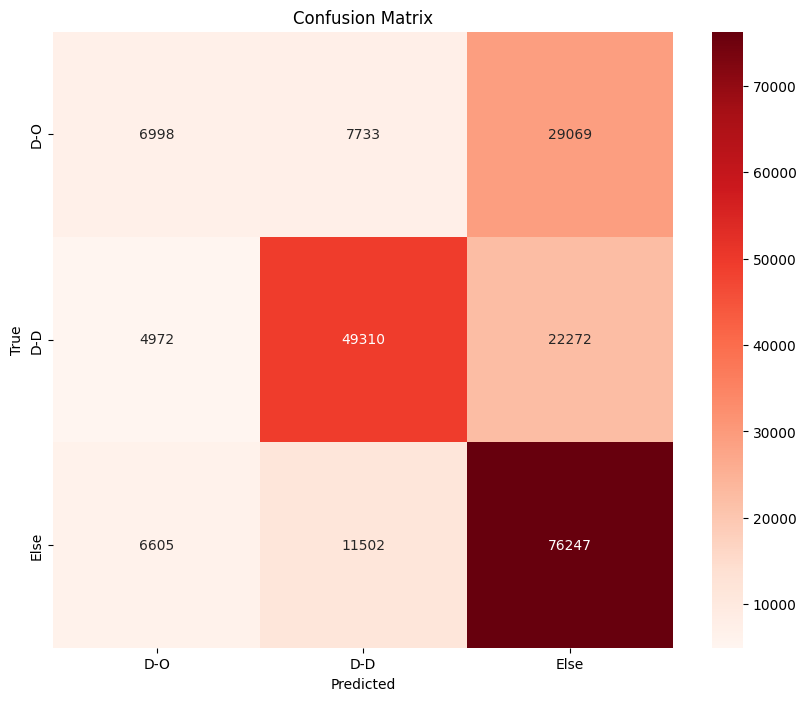

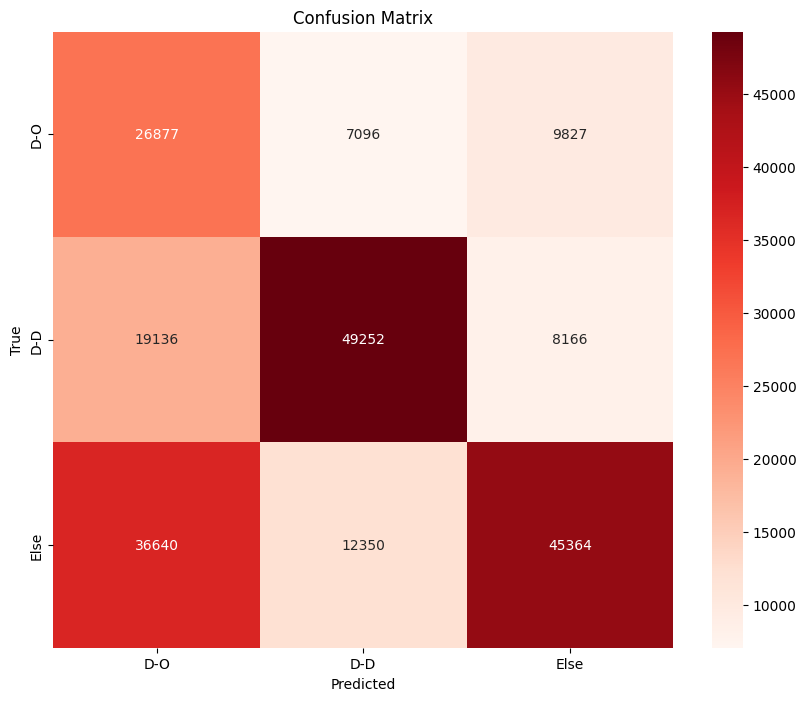

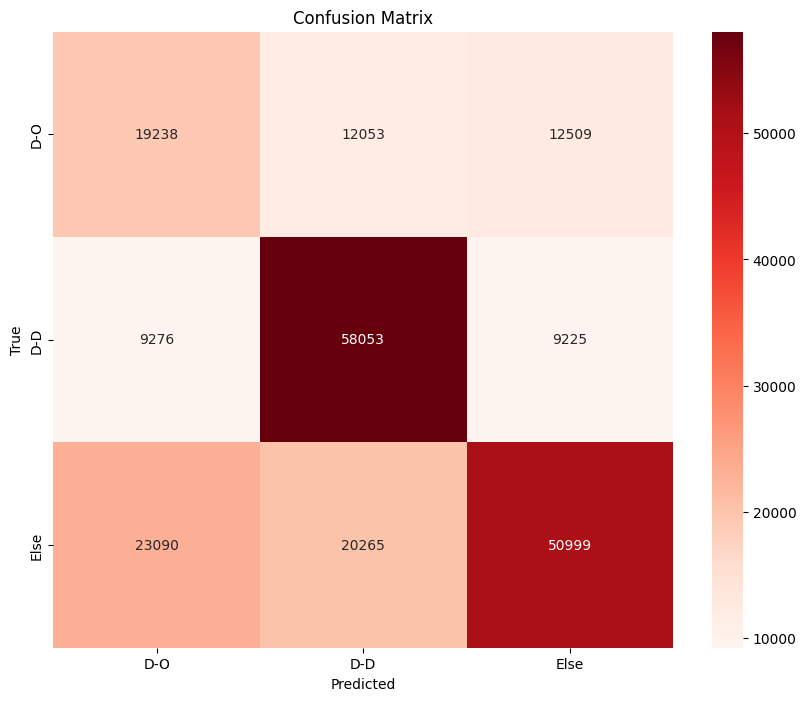

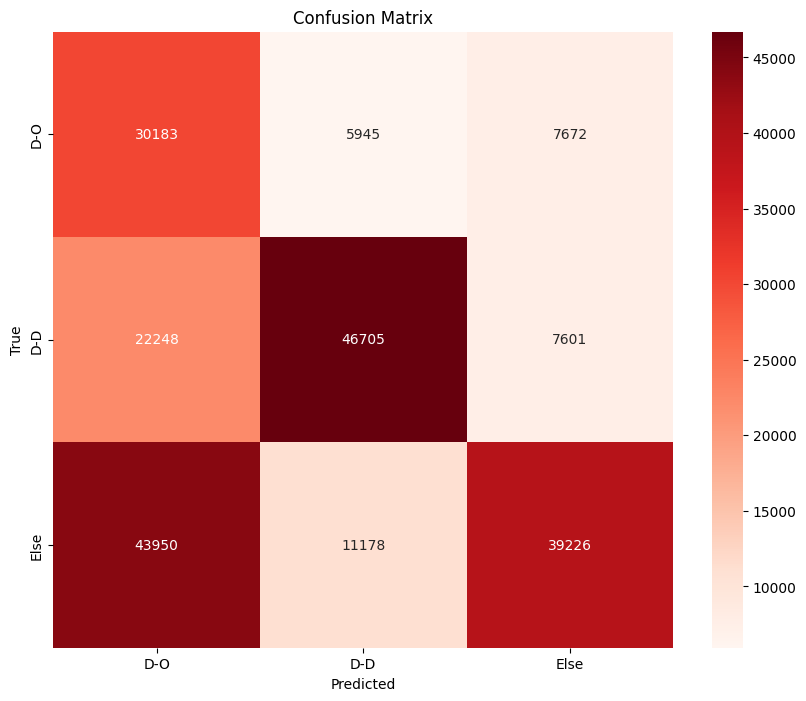

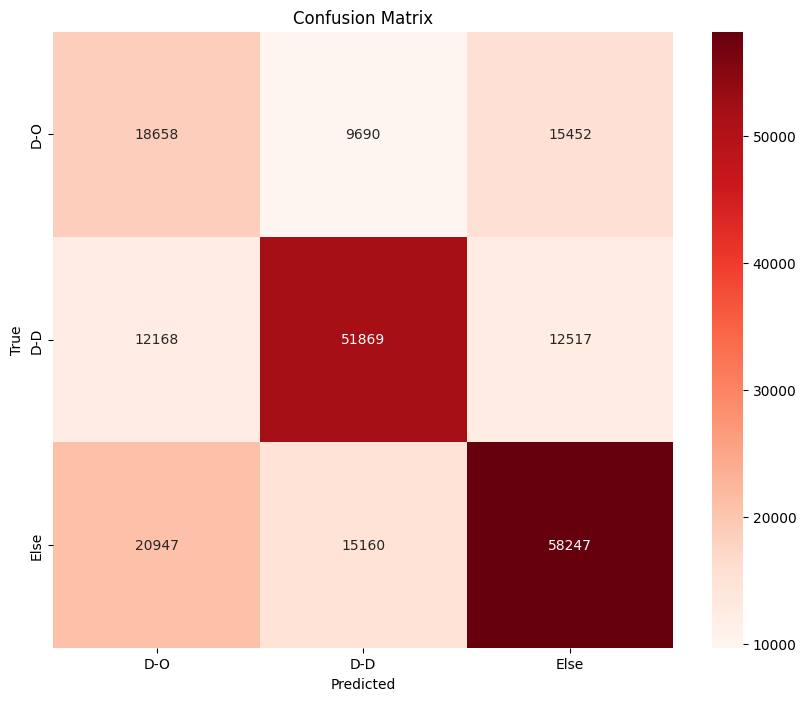

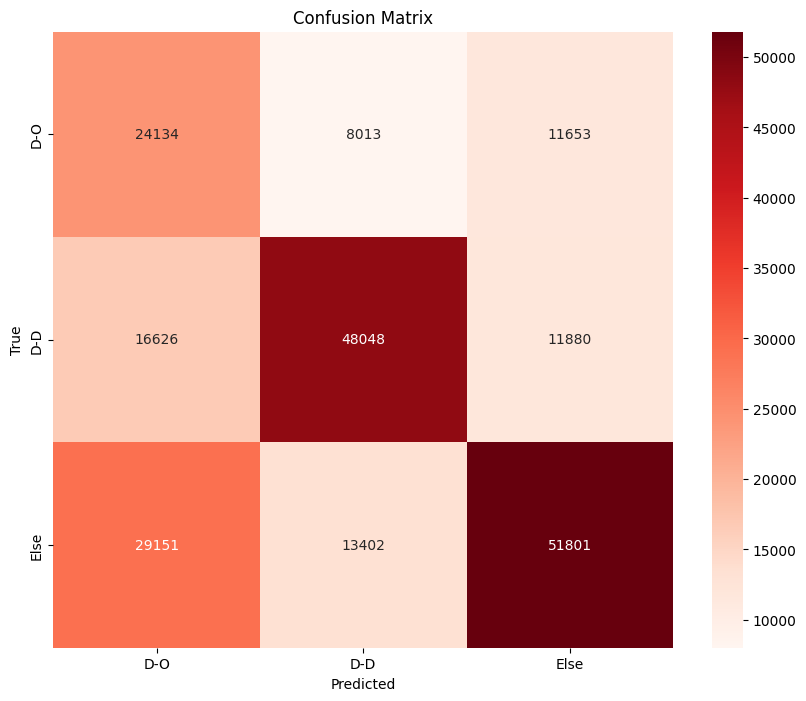

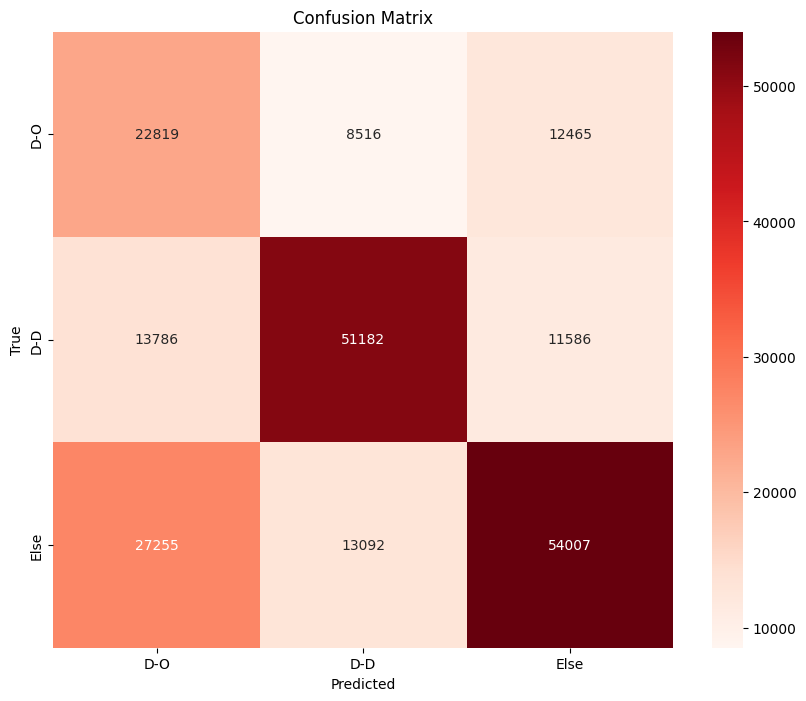

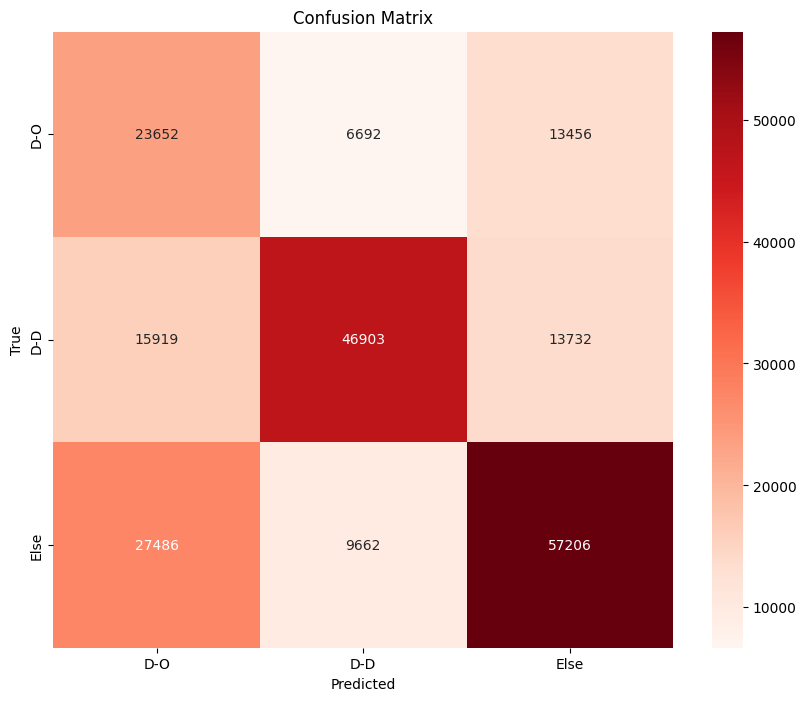

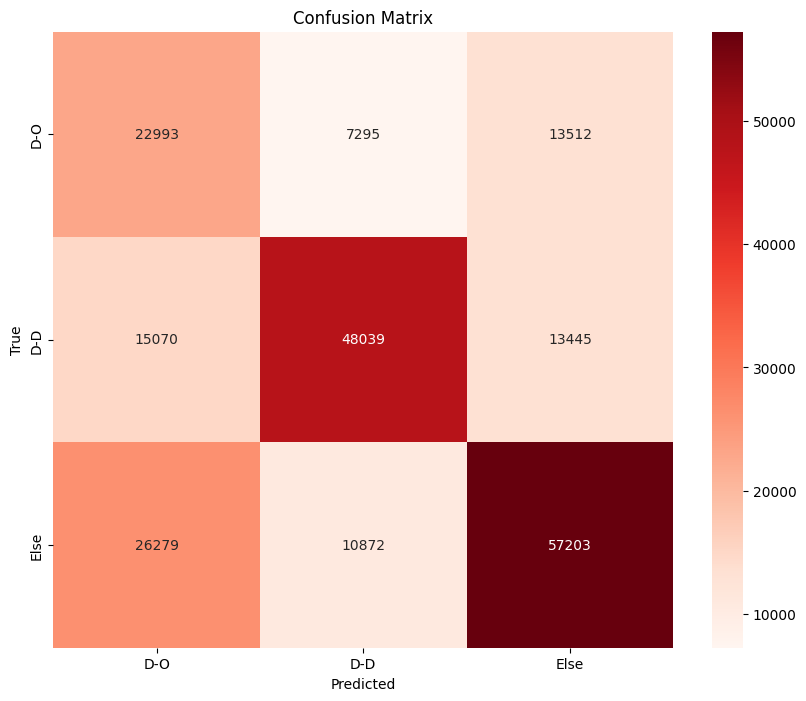

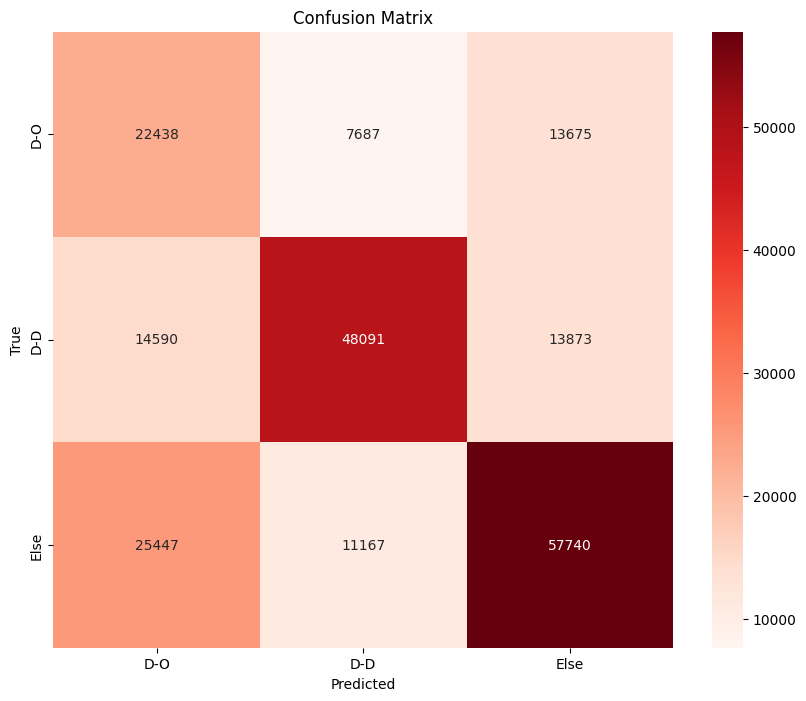

TrainOutput(global_step=2890, training_loss=0.5016064561362085, metrics={'train_runtime': 1746.454, 'train_samples_per_second': 13.215, 'train_steps_per_second': 1.655, 'total_flos': 3024821431078944.0, 'train_loss': 0.5016064561362085, 'epoch': 10.0})

In [9]:
# Train the model using the Trainer instance
trainer.train()

In [10]:
# Save model
model.save_pretrained("esm2_35m_finetune_outputs/my_model_dir")
# Save tokens
tokenizer.save_pretrained("esm2_35m_finetune_outputs/tokenizer_dir")
# Retrieve the log history from the trainer state
log_history = trainer.state.log_history
df_log = pd.DataFrame(log_history)

# Save the log history to a CSV file
df_log.to_csv("esm2_35m_finetune_outputs/training_logs.csv", index=False)